In [1]:
import pandas as pd

train_test_data = pd.read_csv('../data/labeled_dataset_marcelo.csv')
validation_data = pd.read_csv('../data/validation.csv')

In [2]:
#against = train_test_data[train_test_data.label =='AGAINST'].sample(n=5000, random_state=44)
#none = train_test_data[train_test_data.label =='NONE'].sample(n=5000, random_state=44)
#favor = train_test_data[train_test_data.label =='FAVOR'].sample(n=5000, random_state=44)
#train_test_data = pd.concat([against,favor,none])
#train_test_data = train_test_data.reset_index().drop(columns=['index'])
#train_test_data


<AxesSubplot: xlabel='label', ylabel='count'>

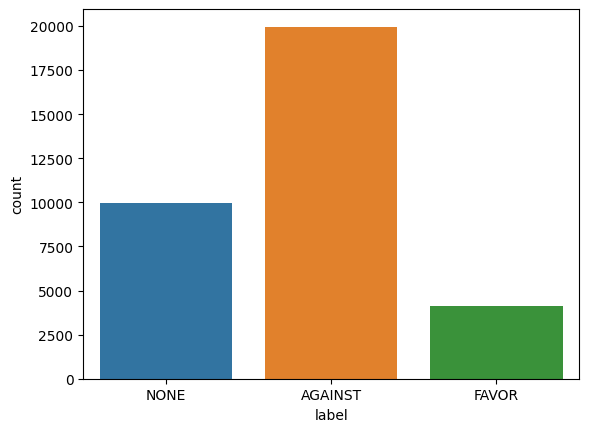

In [3]:
import seaborn as sns

sns.countplot(x=train_test_data['label'], label = 'count')

<AxesSubplot: xlabel='target', ylabel='count'>

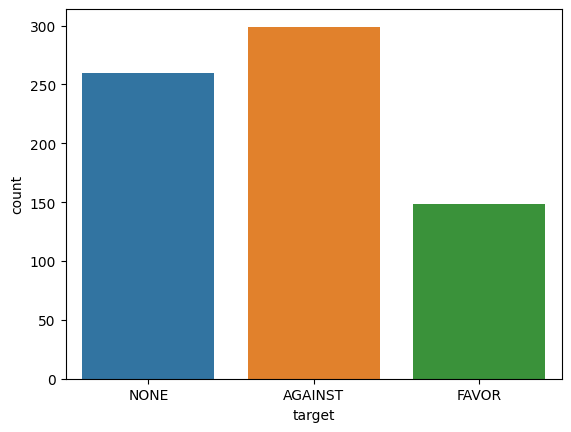

In [4]:
sns.countplot(x=validation_data['target'], label = 'count')

In [5]:
import sklearn
from sklearn.model_selection import train_test_split

train_test_data["label"] = train_test_data["label"].replace(["FAVOR", "NONE","AGAINST"],[0, 1, 2])

X = train_test_data['text']
y = train_test_data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=333, test_size=0.3)

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

NGRAM_RANGE = (1, 2)
TOKEN_MODE = 'word'
MIN_DOCUMENT_FREQUENCY = 2

def ngram_vectorize(X_train, X_test):

    kwargs = {
        'ngram_range': NGRAM_RANGE,
        'dtype': 'float64',
        'strip_accents': 'unicode',
        'decode_error': 'replace',
        'analyzer': TOKEN_MODE,
        'min_df': MIN_DOCUMENT_FREQUENCY,
    }

    vectorizer = TfidfVectorizer(**kwargs)
    x_train = vectorizer.fit_transform(X_train)
    x_test = vectorizer.transform(X_test)
  
    return x_train, x_test, vectorizer

In [7]:
X_train_vectorized, X_test_vectorized, vectorizer  = ngram_vectorize(X_train, X_test)

/home/andre/Documentos/Workspace/mestrado/dissertacao/venv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:2019: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float64 'dtype' will be converted to np.float64.
  warnings.warn(


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(random_state=42, multi_class="auto",class_weight = "balanced", solver="liblinear")
model.fit(X_train_vectorized,y_train)

y_pred = model.predict(X_test_vectorized)

In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.74      0.75      1222
           1       0.81      0.76      0.78      2988
           2       0.86      0.90      0.88      6003

    accuracy                           0.84     10213
   macro avg       0.81      0.80      0.80     10213
weighted avg       0.84      0.84      0.84     10213



In [10]:
vectorizer_validation = vectorizer.transform(validation_data.text).toarray()
y_val_predict = model.predict(vectorizer_validation)
y_val_true = validation_data.target.replace(["FAVOR", "NONE","AGAINST"],[0, 1, 2]).to_numpy()

In [11]:
print(classification_report(y_val_true, y_val_predict))

              precision    recall  f1-score   support

           0       0.64      0.39      0.49       148
           1       0.65      0.60      0.62       260
           2       0.55      0.70      0.62       299

    accuracy                           0.60       707
   macro avg       0.61      0.56      0.57       707
weighted avg       0.61      0.60      0.59       707

